# Dangerous Accessible Space / Expected Pass Completion

<b>Dangerous accessible space (DAS)</b> is a flavor of EPV (expected possession value) based on <b>physical pass simulations</b>. For every frame where a player is in possession, the model simulates multiple ground passes of that player with different speeds and angles, such that all possible directions are covered. Then it calculates the likelihood that each player can intercept a given pass at every position along its simulated trajectory. This likelihood can then be weighted by some measure of goal threat, aggregated by team, and integrated across the pitch to give a numerical value, describing the amount of dangerous space that is accessible in the current situation.

The formula to calculate the probability to intercept or receive the ball along a pass trajectory for a given player $r$ boils down to:

$$\frac{dP_r(t)}{dt} = P_0(t)a_r(t)$$

Where $\frac{dP_r(t)}{dt}$ is the probability density that player $r$ intercepts the ball at time $t$ along the pass trajectory, $P_0(t)$ is the probability that the ball has not been intercepted yet until time $t$ and $a_r(t)$ is the transition rate from $P_0(t)$ (not intercepted) to $P_r(t)$ (intercepted by $r$). The calculation of $a_r(t)$ is based on the difference between the arrival time of a player and the ball like this:

$$a_r(t) = \frac{1}{1 + e^{b_0 + b_1(T_r(t) - t)}}\frac{1}{\sigma(v_B(t))}$$

Where $b_0$ and $b_1$ are parameters, $T_r(t)$ is the arrival time of the player, $t$ is the arrival time of the ball and $\sigma(v_B(t))$ is a function that gives the model an additional factor that is dependent on the ball speed $v_B(t)$ to take into account that the ability to intercept varies with the speed of the ball. Essentially, this means that the earlier a player arrives relative the ball, the higher the transition rate $a_r(t)$ (and, accordingly, the interception probability density $\frac{dP_r(t)}{dt}$).

The other half of the formula, $P_0(t)$, is calculated based on the integral of the transition rates of all players up until time $t$. Intuitively, if a lot of players had high interception rates in the past, $P_0(t)$ will be small and diminish all $\frac{dP_r(t)}{dt}$ values further down the trajectory. In other words, the likelihood of interception is low if the pass has likely been intercepted before, even if the current interception rate is high. 

$$P_0(t) = e^{\int_{0}^{t}(-\sum_{r \in R}^{}a_r(\tau))d\tau}$$

By aggregating and plotting the resulting interception probability densities $\frac{dP_r(t)}{dt}$ spatially, we obtain the <b>accessible space</b> field (left image) of a team. If we add a notion of value like Expected Goals we obtain <b>dangerous accessible space</b> (right image) whose area integral serves as our final metric, DAS.

<table>
  <tr>
    <td style="text-align: center;">
    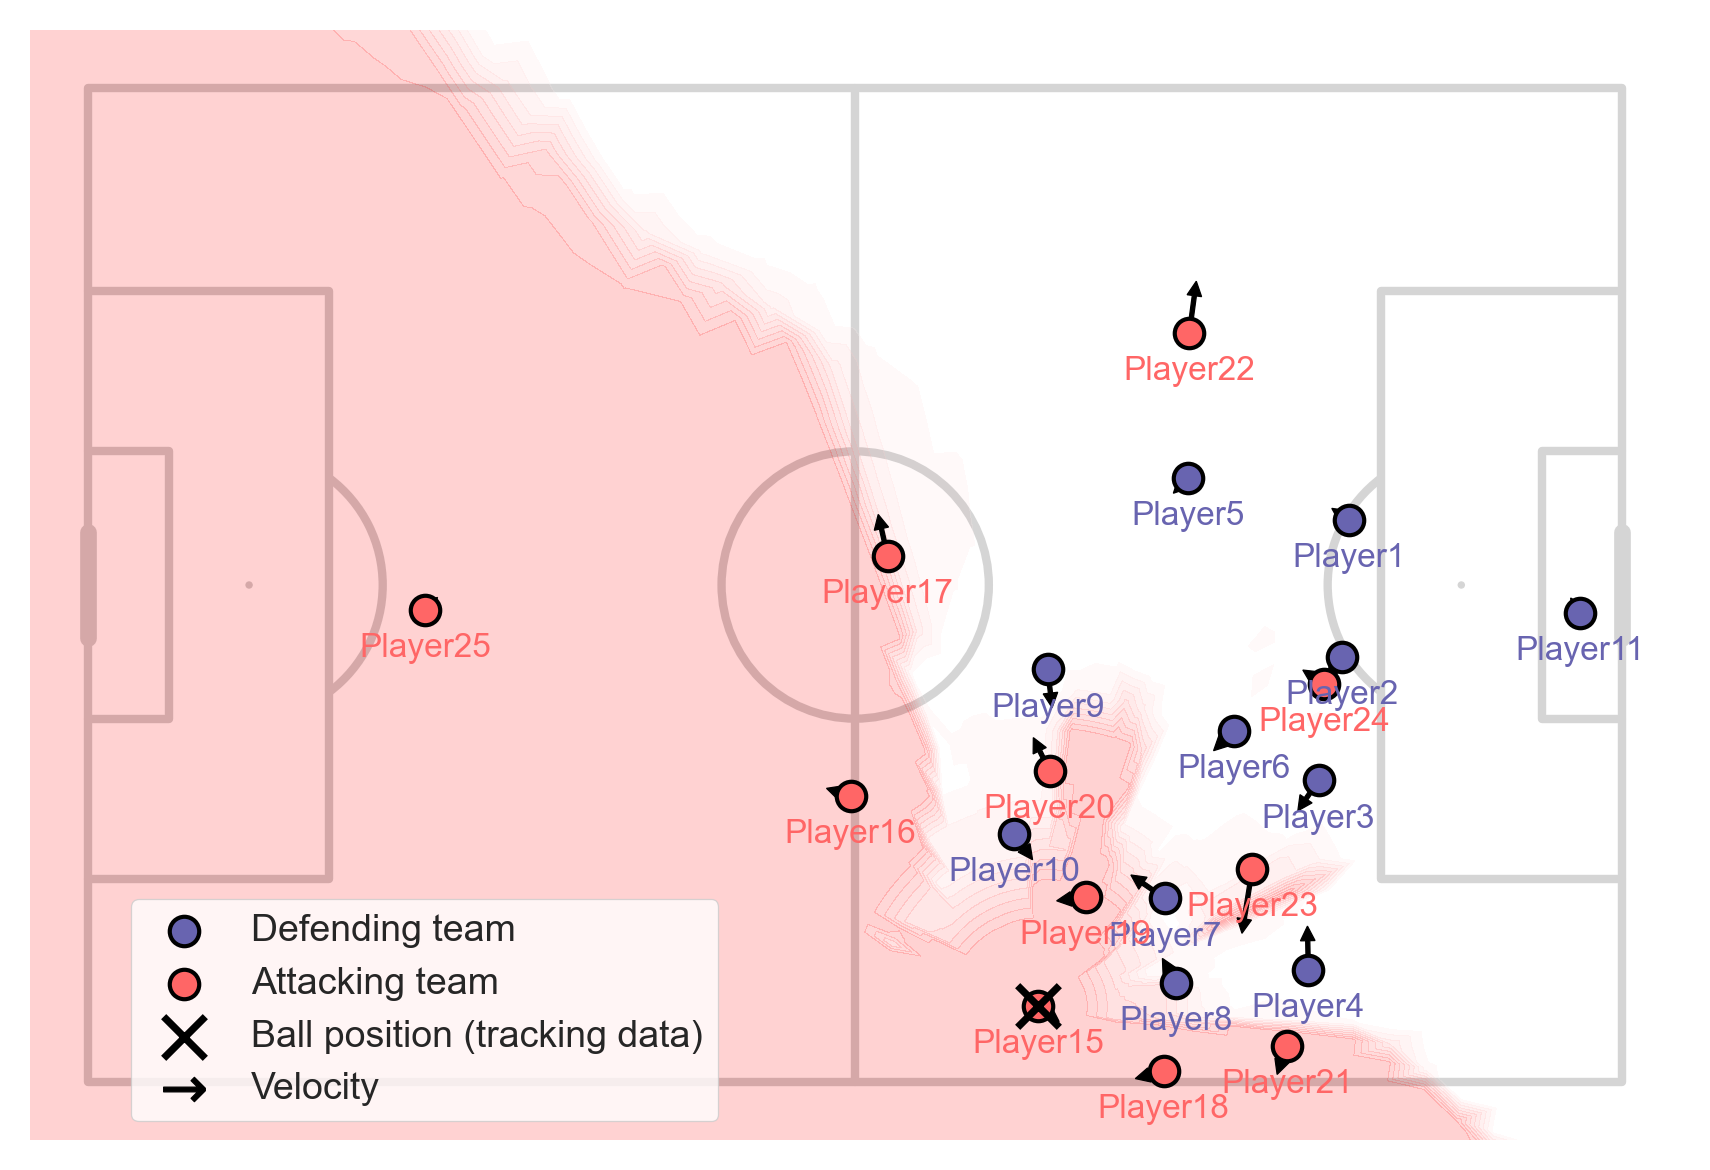
      <p style="text-align: center;">Accessible space</p>
    </td>
    <td style="text-align: center;">
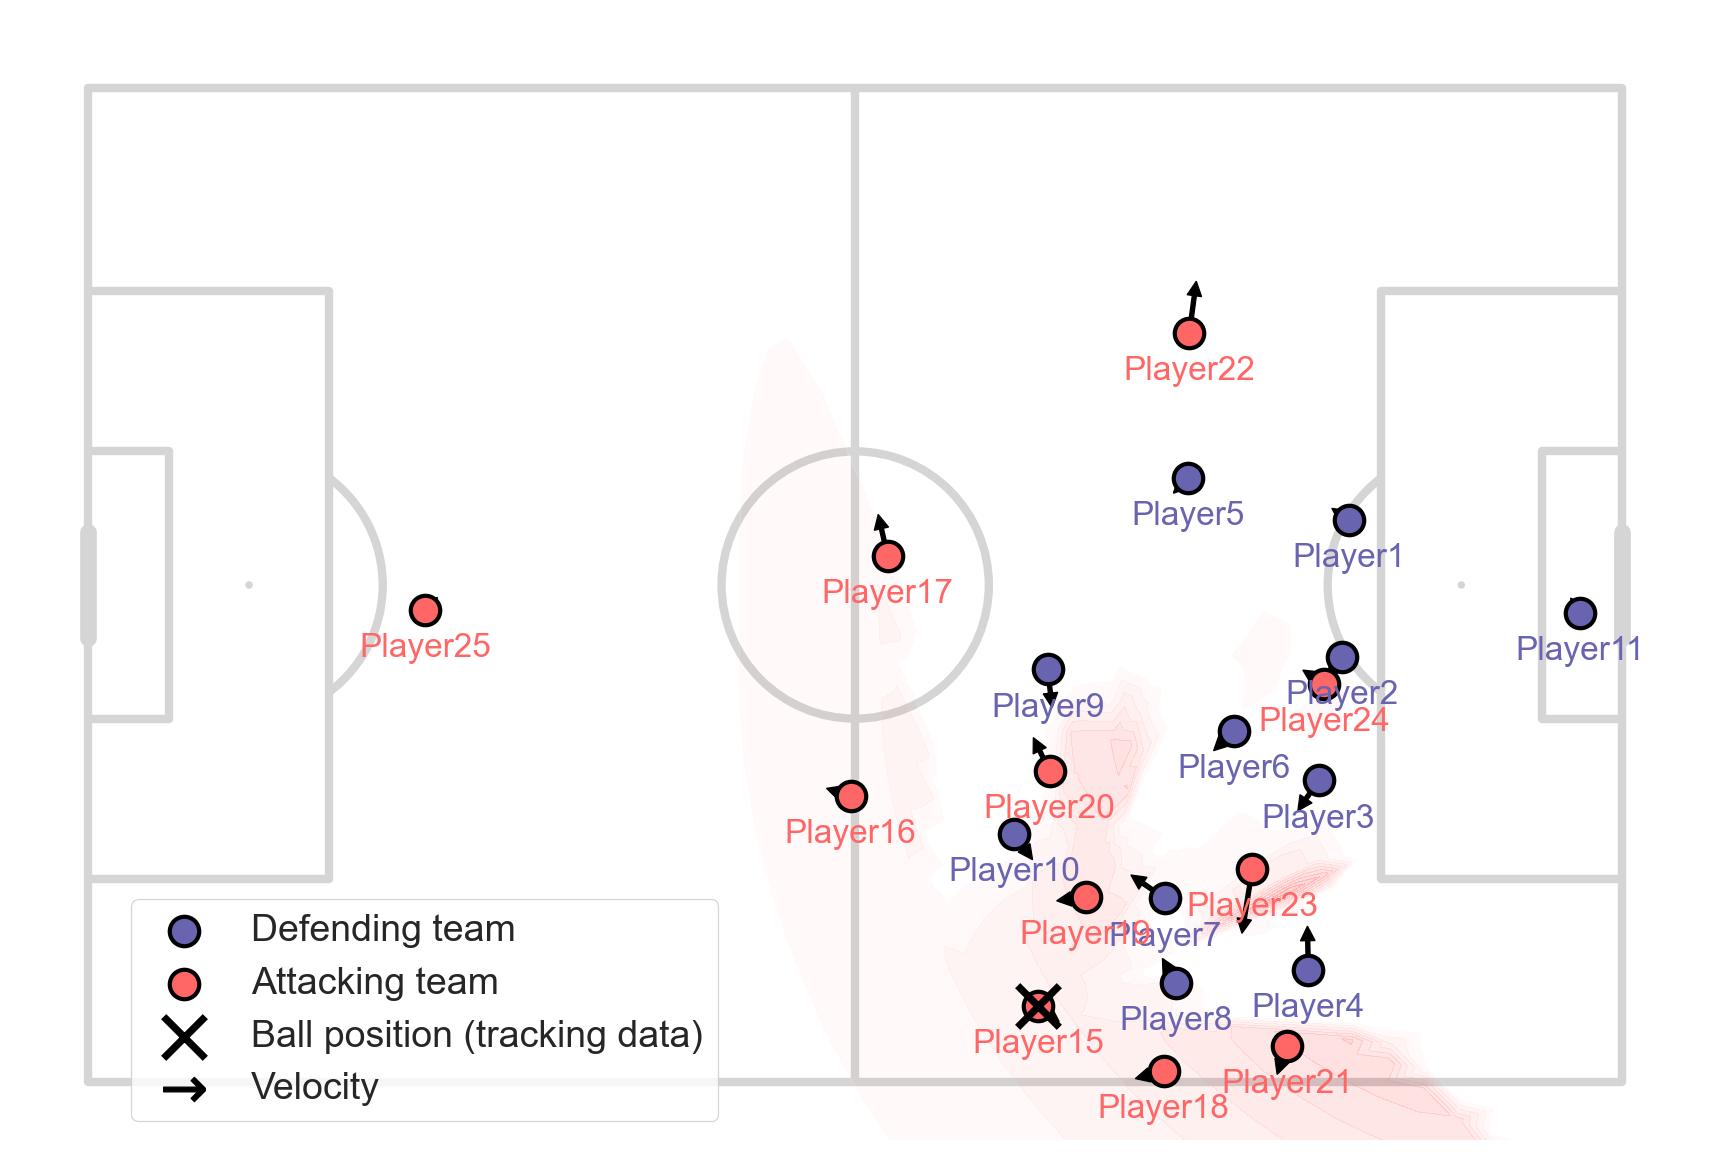
        <p style="text-align: center;">Dangerous accessible space</p>
    </td>
  </tr>
</table>




This is the gist of DAS and the physical pass simulations behind it. More details and explanations can be found in the publication of the model by Bischofberger and Baca (2025)$^1$ and the corresponding repository$^2$.

In databallpy, we can use the ``add_dangerous_accessible_space`` function to access team-level DAS for every frame of tracking data.

---

$^1$ Bischofberger, J., & Baca, A. (2025). Dangerous accessible space: A unified model of space and value in team sports [Preprint]. Research Square. https://doi.org/10.21203/rs.3.rs-6932689/v1

$^2$ https://github.com/jonas-bischofberger/accessible-space

In [1]:
from databallpy import get_open_match

game = get_open_match(provider="metrica")
game.tracking_data.add_dangerous_accessible_space()
game.tracking_data[["period_id", "frame", "team_in_possession", "dangerous_accessible_space"]].dropna()

C:\Users\j.bischofberger\OneDrive - VfB Stuttgart 1893 AG\Desktop\code\databallpy\.venv\Lib\site-packages\pandera\_pandas_deprecated.py:157: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)
2025-11-06 17:36:13.795 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainT

,period_id,frame,team_in_possession,dangerous_accessible_space
365,1,366,home,0.137264
366,1,367,home,0.135954
367,1,368,home,0.135291
368,1,369,home,0.135532
369,1,370,home,0.135628
...,...,...,...,...
9629,1,9630,home,7.652853
9630,1,9631,home,7.569845
9631,1,9632,home,7.387559
9632,1,9633,home,7.181813


Plotting DAS of both teams in a line graph highlights how the possession phases of the teams unfold during the game.

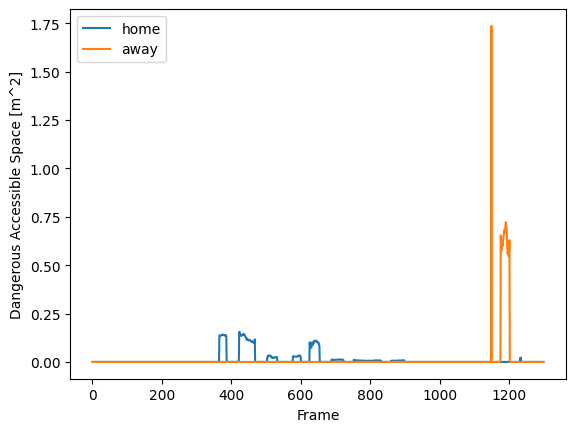

In [2]:
import matplotlib.pyplot as plt

df = game.tracking_data[game.tracking_data["frame"] < 1300].copy()  # Example slice

plt.figure()
plt.xlabel("Frame")
plt.ylabel("Dangerous Accessible Space [m^2]")
for team in game.tracking_data["team_in_possession"].dropna().unique():
    dfx = df.copy()
    i_team_possession = dfx["team_in_possession"] == team
    dfx.loc[~i_team_possession, "dangerous_accessible_space"] = 0.0  # set DAS to 0 while the opponent or no one controls the ball
    plt.plot(dfx["frame"], dfx["dangerous_accessible_space"], label=f"{team}")

plt.legend()
plt.show()

The plot shows a relatively harmless attack by the home team in the beginning, followed by a short period of danger from the away team, possibly through a ball win or a set piece.

Aggregated DAS for each team gives us a summary of their threat during the match. In the table, we can see that the home team had higher total DAS values while the away team had higher DAS values on average, pointing to a style of play more focused on counterattacking or set pieces.

In [3]:
dfg = game.tracking_data.groupby("team_in_possession").agg(
    total_das=("dangerous_accessible_space", "sum"),
    max_das=("dangerous_accessible_space", "max"),
    mean_das=("dangerous_accessible_space", "mean"),
)
dfg["total_das"] /= game.tracking_data.frame_rate  # divide by frame rate as normalization
dfg

,total_das,max_das,mean_das
team_in_possession,,,
away,21.746813,10.744655,0.757201
home,34.762762,18.474985,0.487693


We can also access the expected completion rate of individual passes using the ```add_expected_completion``` function of databallpy's ```Game``` object:

In [4]:
game.add_expected_completion()

game.event_data[["event_id", "databallpy_event", "original_event", "player_name", "is_successful", "expected_completion"]]

C:\Users/j.bischofberger/OneDrive - VfB Stuttgart 1893 AG/Desktop/code/databallpy\databallpy\features\differentiate.py:257: DataBallPyWarning: No values added to the tracking data. Consider setting `allow_overwrite` to True
  warnings.warn(


,event_id,databallpy_event,original_event,player_name,is_successful,expected_completion
0,0,None,set piece,Player 10,<NA>,NaN
1,1,pass,pass,Player 10,True,0.626062
2,2,dribble,carry,Player 7,True,NaN
3,3,pass,pass,Player 7,True,0.935557
4,4,dribble,carry,Player 8,True,NaN
...,...,...,...,...,...,...
3615,3615,pass,pass,Player 33,True,0.942258
3616,3616,pass,pass,Player 20,True,0.951644
3617,3617,dribble,carry,Player 20,True,NaN
3618,3618,dribble,carry,Player 28,False,NaN


The resulting value can be used for example to calculate over- and underperformance which highlights players who complete difficult passes.

In [5]:
# Prepare data
i_pass = game.event_data["original_event"].isin(["pass", "ball lost", "ball out"]) & (game.event_data["expected_completion"].notna()) & (game.event_data["is_successful"].notna())
game.event_data["is_successful"] = game.event_data["is_successful"].fillna(False)

# Aggregate by player
dfg = game.event_data.loc[i_pass].groupby(["team_id", "player_name"]).agg(
    expected_passes=("expected_completion", "sum"),
    n_successful_passes=("is_successful", "sum"),
    n_passes=("is_successful", "count"),
)
dfg["pass_completion_rate"] = dfg["n_successful_passes"] / dfg["n_passes"]
dfg["expected_pass_completion_rate"] = dfg["expected_passes"] / dfg["n_passes"]
dfg["xc_overperformance"] = dfg["pass_completion_rate"] - dfg["expected_pass_completion_rate"]
dfg["n_successful_passes_overperformance"] = dfg["n_successful_passes"] - dfg["expected_passes"]

dfg.reset_index().sort_values("n_successful_passes_overperformance", ascending=False)

,team_id,player_name,expected_passes,n_successful_passes,n_passes,pass_completion_rate,expected_pass_completion_rate,xc_overperformance,n_successful_passes_overperformance
0,FIFATMA,Player 1,57.207380,65,67,0.970149,0.853841,0.116308,7.79262
14,FIFATMA,Player 7,51.503540,59,62,0.951613,0.830702,0.120911,7.49646
13,FIFATMA,Player 6,45.523972,53,53,1.0,0.858943,0.141057,7.476028
21,FIFATMB,Player 22,32.619183,40,42,0.952381,0.776647,0.175734,7.380817
12,FIFATMA,Player 5,37.242988,44,47,0.93617,0.792404,0.143766,6.757012
25,FIFATMB,Player 26,18.964752,25,25,1.0,0.75859,0.24141,6.035248
4,FIFATMA,Player 13,42.220378,48,49,0.979592,0.86164,0.117951,5.779622
22,FIFATMB,Player 23,38.400277,44,44,1.0,0.872734,0.127266,5.599723
24,FIFATMB,Player 25,29.939261,35,36,0.972222,0.831646,0.140576,5.060739
11,FIFATMA,Player 4,41.512255,46,48,0.958333,0.864839,0.093495,4.487745


Internally, ``databallpy`` calls functions from the ``accessible-space`` package. That package supports additional analyses, for example, you can obtain player-level DAS values as follows:

In [6]:
import accessible_space.interface

df_long = game.tracking_data.to_long_format()
df_long["team"] = df_long["column_id"].str[:4]
res = accessible_space.interface.get_individual_dangerous_accessible_space(df_long, frame_col="frame", period_col="period_id", player_col="column_id", team_col="team", x_col="x", y_col="y", vx_col="vx", vy_col="vy", team_in_possession_col="team_in_possession", player_in_possession_col="player_possession")
df_long["AS_player"] = res.player_acc_space
df_long["DAS_player"] = res.player_das
df_long[["frame", "column_id", "team", "team_in_possession", "AS_player", "DAS_player"]].dropna().drop_duplicates().head(20)

Simulating passes: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17/17 [05:22<00:00, 18.95s/chunk]


,frame,column_id,team,team_in_possession,AS_player,DAS_player
144126,366,home_11,home,home,1923.803828,0.006026
144127,367,home_11,home,home,1919.857537,0.005966
144128,368,home_11,home,home,1919.200618,0.005968
144129,369,home_11,home,home,1915.738439,0.005918
144130,370,home_11,home,home,1914.047778,0.005892
144131,371,home_11,home,home,1911.291920,0.005860
144132,372,home_11,home,home,1905.833896,0.005785
144133,373,home_11,home,home,1896.090445,0.005645
144134,374,home_11,home,home,1891.421664,0.005568
144135,375,home_11,home,home,1888.834073,0.005542


See the Github repository of ``accessible-space`` for more details and functionality.$^2$